In [1]:
%matplotlib inline

In [2]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import xarray as xr

import ipywidgets as widgets
import xgcm

from numpy import pi as π

In [3]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# Load datasets

## Constants

In [4]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3

## Grid

MOM calls coordinates different things in different outputs. This enforces as uniform standard.

In [5]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

Vertical coordinates are annoyingly not in `ocean_geometry.nc`. We load them from the initial conditions and add them to the grid.

In [7]:
grid = xr.open_dataset('OUTPUT/ocean_geometry.nc').rename(coord_map_h)
ic = xr.open_dataset('OUTPUT/MOM_IC.nc').squeeze().rename({**coord_map_h, **coord_map_v})

grid['zi'] = ic.zi
grid['zl'] = ic.zl

grid['fh'] = 2*Ω*sind(grid.yh)
grid['fq'] = 2*Ω*sind(grid.yq)

grid['βh'] = 2*Ω*cosd(grid.yh)/a
grid['βq'] = 2*Ω*cosd(grid.yq)/a

grid

<xarray.Dataset>
Dimensions:  (xh: 60, xq: 61, yh: 81, yq: 82, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 3600 days
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
  * zl       (zl) float64 1.035e+03 1.036e+03
Data variables: (12/23)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 ...
    f        (yq, xq) float64 ...
    ...       ...
    dyCuo    (yh, xq) float64 ...
    wet      (yh, xh) float64 ...
    fh       (yh) float64 2.593e-05 2.716e-05 2.839e-05 ... 0.0001022 0.0001028
    fq       (yq) float64 2.532e-05 2.655e-05 2.778e-05 ... 0.0001025 0.0001032
    βh       (yh) float64 2.252e-11 2.249e-11 2.245e-11 ... 1.632e-11 1.622e-11
    βq       (yq) float64 2.254e-11 2.251e-11 2.247e-11 ... 1.627e-11 1.617e-11
Attributes:
    filename:  ./ocean_geometry.nc

In [8]:
grid_op = xgcm.Grid(grid, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (periodic, boundary=None):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (periodic, boundary=None):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (periodic, boundary=None):
  * inner    zl
  * outer    zi

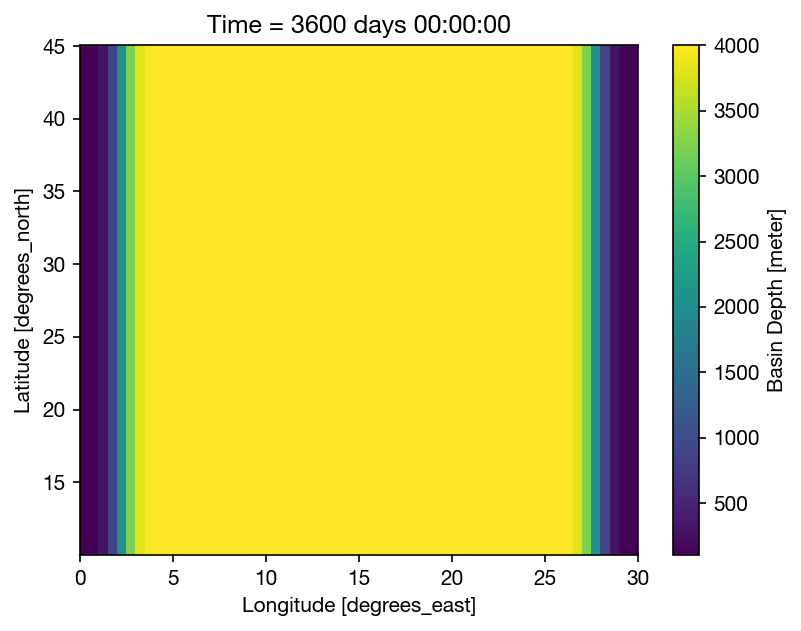

In [10]:
grid.D.plot()

## Forcing

In [27]:
forcing = xr.open_dataset('INPUT/forcing.nc')
forcing

<xarray.Dataset>
Dimensions:   (xh: 60, xq: 60, yh: 81, yq: 81)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 ...
    STRESS_Y  (yq, xh) float64 ...

## Statistics

In [12]:
stats = xr.open_dataset('OUTPUT/ocean.stats.nc')
stats

<xarray.Dataset>
Dimensions:        (Interface: 3, Layer: 2, Time: 36002)
Coordinates:
  * Layer          (Layer) float64 1.035e+03 1.036e+03
  * Interface      (Interface) float64 1.034e+03 1.036e+03 1.037e+03
  * Time           (Time) timedelta64[ns] 0 days 1 days ... 36000 days
Data variables:
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    Mass           (Time) float64 ...
    Mass_chg       (Time) float64 ...
    Mass_anom      (Time) float64 ...
    max_CFL_trans  (Time) float64 ...
    max_CFL_lin    (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

## Prognostic variables

In [14]:
prog = xr.open_mfdataset('OUTPUT/prog*.nc')

"e" is 4-dimensional. netcdf files and objects are index [n,k,j,i] for the time-, vertical-, meridional-, zonal-axes.

Let's take a quick look at the first record [n=0] of the top interface [k=0]. 

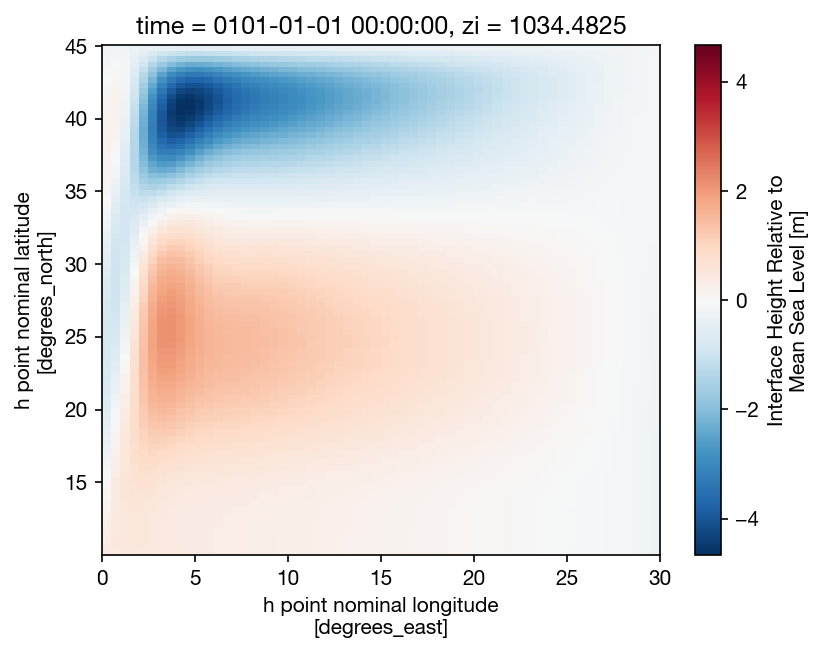

In [15]:
pc = (prog.e.isel(time=-1, zi=0)).plot()

# Plot

## Statistics

In [19]:
stats.Time.values.astype('timedelta64[D]').astype(float)/360

array([0.00000000e+00, 2.77777778e-03, 5.55555556e-03, ...,
       9.99944444e+01, 9.99972222e+01, 1.00000000e+02])

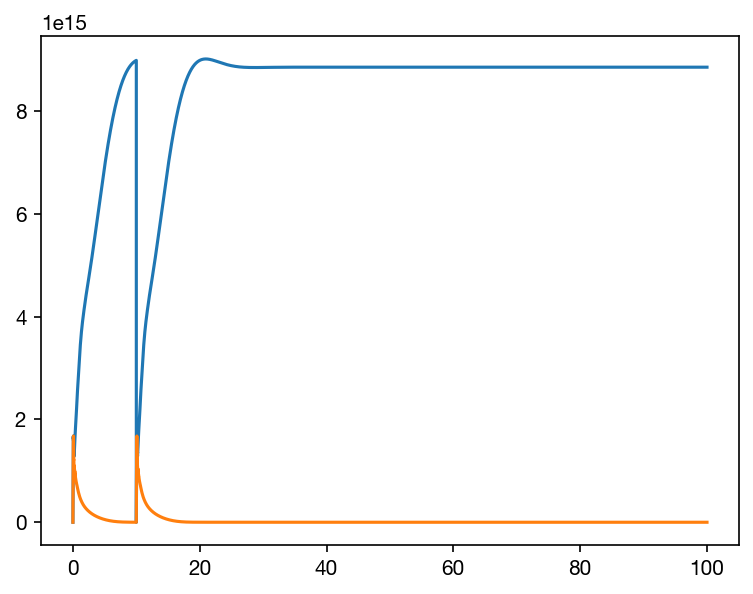

In [20]:
years = stats.Time.values.astype('timedelta64[D]').astype(float)/360

plt.plot(years, stats.KE)

## SSH

In [21]:
fld = prog.e.isel(zi=0)

vmax = float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

def plot_ssh(record, step):
    plt.contourf(fld.xh, fld.yh, fld.isel(time=record), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=1199), IntSlider(value=0, descript…

## f On H

In [30]:
360*4

1440

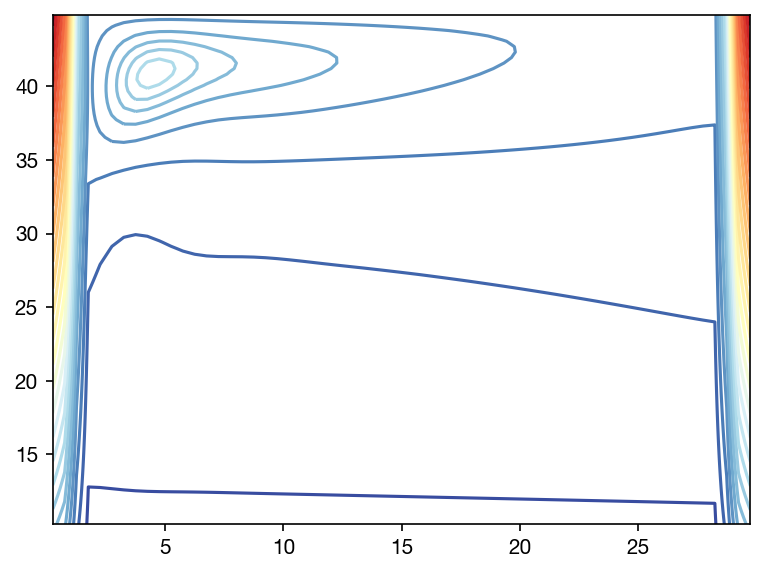

In [26]:
fOnH = grid.fh/prog.h.isel(zl=0,time=-1)
plt.contour(grid.xh, grid.yh, fOnH, 31)

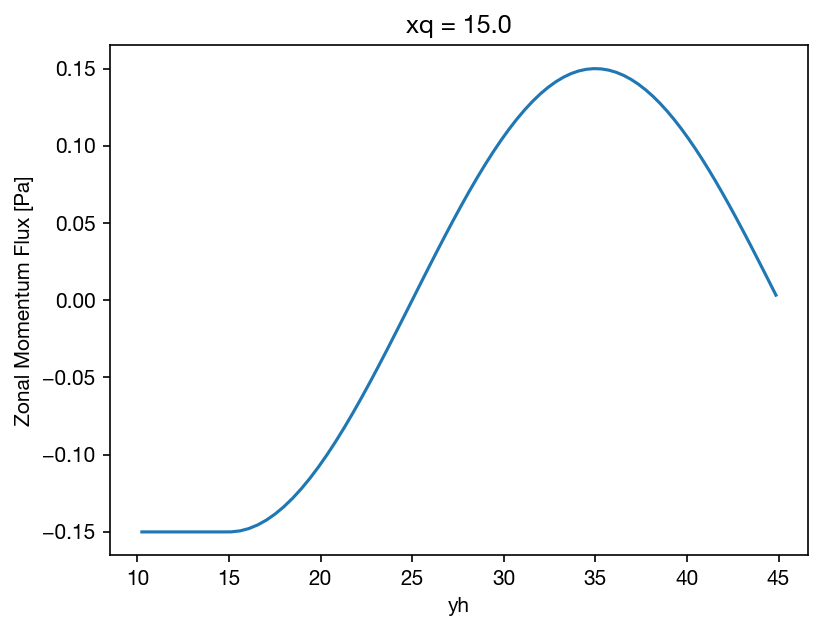

In [29]:
forcing.STRESS_X.isel(xq=30).plot()

## Plot thickness anomaly

In [133]:
fld = prog.h.isel(zl=0) - ic.h.isel(zl=0)

vmax = float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

def plot_ssh(record, step):
    
    plt.contourf(fld.xh, fld.yh, fld.isel(time=record), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=1199), IntSlider(value=0, descript…

In [134]:
fld = prog.e.sel(yh=25, method='nearest').isel(zi=0)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=1199), IntSlider(value=0, descript…

In [111]:
fld = prog.e.sel(yh=41, method='nearest').isel(zi=0)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=119), IntSlider(value=0, descripti…

In [135]:
fld = prog.e.sel(yh=25, method='nearest').isel(zi=1)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.plot(fld.xh, fld.isel(time=0))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=1199), IntSlider(value=0, descript…

In [136]:
fld = prog.e.sel(yh=41, method='nearest').isel(zi=1)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.plot(fld.xh, fld.isel(time=0))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=1199), IntSlider(value=0, descript…

## Barotropic streamfunction

In [137]:
ds = xr.open_mfdataset('cont*.nc', decode_times=False)
cont = ds
ds.close()
cont

<xarray.Dataset>
Dimensions:     (nv: 2, time: 1200, xh: 60, xq: 61, yh: 81, yq: 82, zl: 2)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.036e+03
  * time        (time) float64 15.0 45.0 75.0 ... 3.592e+04 3.596e+04 3.598e+04
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    uh          (time, zl, yh, xq) float32 dask.array<chunksize=(120, 2, 81, 61), meta=np.ndarray>
    vh          (time, zl, yq, xh) float32 dask.array<chunksize=(120, 2, 82, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

In [138]:
psiB = grid_op.cumsum(cont.vh.sum(dim='zl'), axis='X', to='outer', boundary='fill')/1e6

In [139]:
fld = psiB

vmax = float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

def plot_ssh(record, step):
    
    plt.contourf(fld.xq, fld.yq, fld.isel(time=record), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.show()

NT = len(cont.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=1199), IntSlider(value=0, descript…

## Baroclinic Defomation Radius

In [127]:
gprime = float(grid.zl.diff(dim='zl')*g/ρ0)

Hbar = prog.h.isel(zl=0)*prog.h.isel(zl=1)/prog.h.sum(dim='zl') # harmonic mean of layer thicknesses

c = np.sqrt(gprime*Hbar)
Ld = np.sqrt(gprime*Hbar)/grid.fh

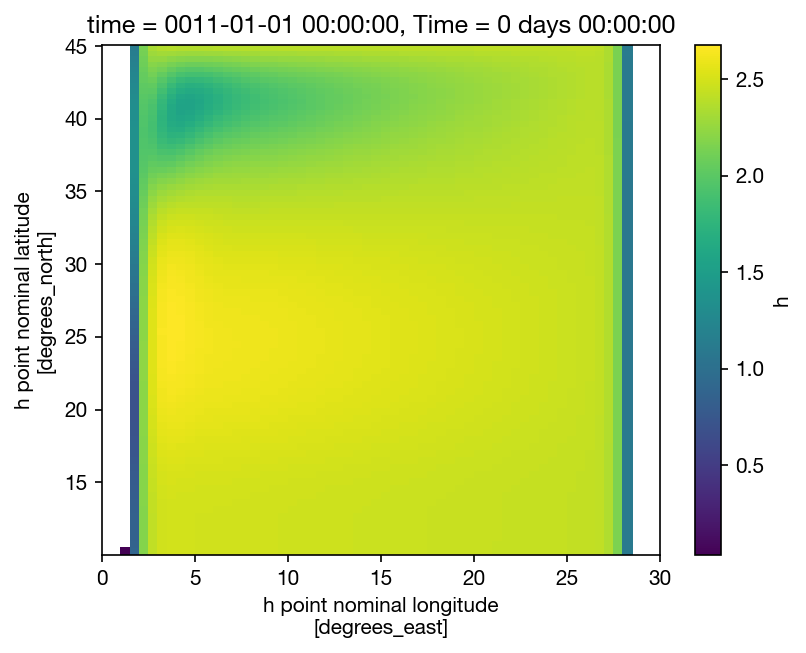

In [128]:
c.where(Ld>1000).isel(time=-1).plot()

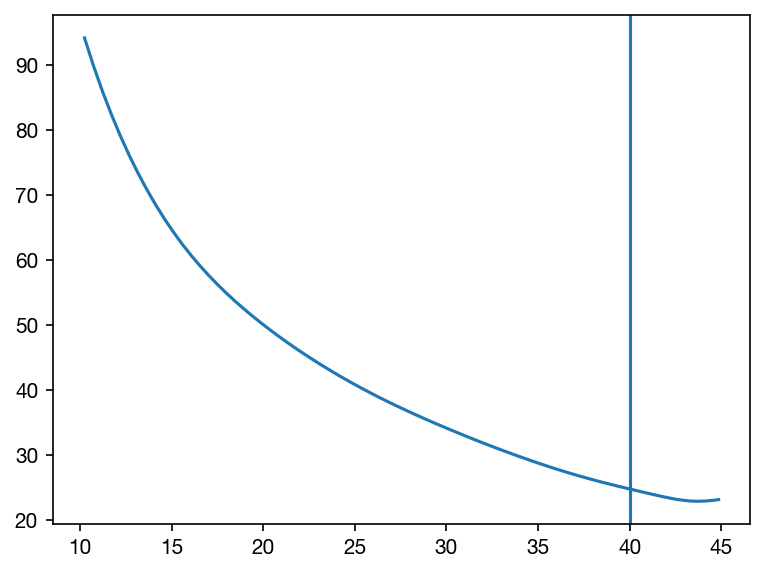

In [74]:
plt.plot(grid.yh, (Ld/1e3).isel(time=-1, xh=30))
plt.axvline(40)

### Basin crossing time

In [81]:
Lx

<xarray.DataArray (yq: 82)>
array([3284653.13152188, 3279558.45921564, 3274230.60430334,
       3268671.510793  , 3262883.19892847, 3256867.7634378 ,
       3250627.37172848, 3244164.26203238, 3237480.74150316,
       3230579.18426921, 3223462.02944496, 3216131.77910359,
       3208590.99621416, 3200842.30254618, 3192888.37654461,
       3184731.95117847, 3176375.81176593, 3167822.79377904,
       3159075.78063102, 3150137.70144927, 3141011.52883679,
       3131700.2766253 , 3122206.9976226 , 3112534.78135734,
       3102686.75182374, 3092666.06522927, 3082475.90774768,
       3072119.49328033, 3061600.06122813, 3050920.87427676,
       3040085.21619746, 3029096.3896658 , 3017957.71410074,
       3006672.52352598, 2995244.16445598, 2983675.99380837,
       2971971.37684481, 2960133.68514222, 2948166.29459589,
       2936072.58345629, 2923855.93040108, 2911519.71264382,
       2899067.30408061, 2886502.0734761 , 2873827.38268993,
       2861046.58494476, 2848163.02313681, 2835180.02818983,
       2822100.91745341, 2808928.9931461 , 2795667.54084431,
       2782319.82801722, 2768889.10260838, 2755378.59166425,
       2741791.50001004, 2728131.00897305, 2714400.27515363,
       2700602.42924394, 2686740.57489426, 2672817.78762712,
       2658837.1137988 , 2644801.56960816, 2630714.14015254,
       2616577.77853035, 2602395.40498996, 2588169.90612456,
       2573904.13411238, 2559600.90600187, 2545263.00304112,
       2530893.17005107, 2516494.11484169, 2502068.50767059,
       2487618.98074321, 2473148.12775389, 2458658.5034671 ,
       2444152.62333778, 2429632.96317033, 2415101.95881498,
       2400562.00590101, 2386015.45960568, 2371464.6344581 ,
       2356911.80417703])
Coordinates:
    Time     timedelta64[ns] 00:00:00
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04

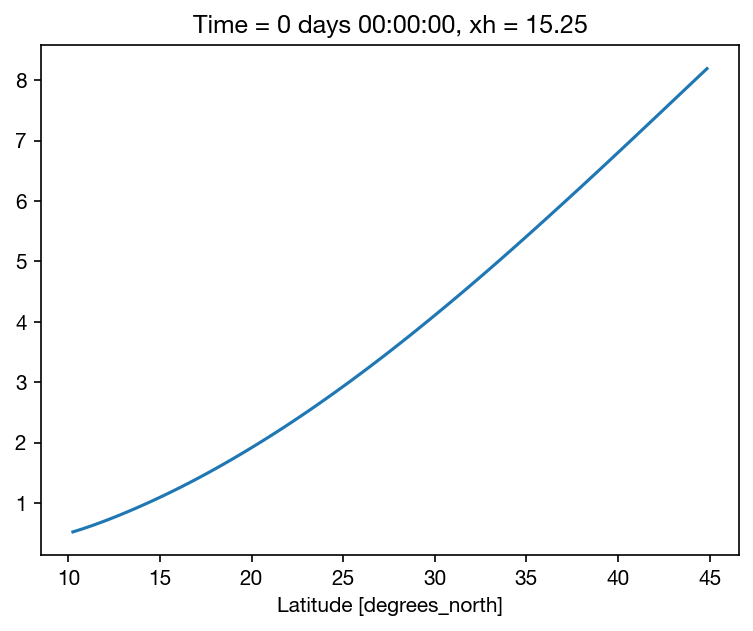

In [85]:
Lx = a*np.deg2rad(grid.xq.isel(xq=-1) - grid.xq.isel(xq=0))*cosd(grid.yh)
T = Lx/(grid.βh*Ld.isel(time=0,xh=30)**2)
(T/3600/24/365).plot()

In [95]:
forcing_diag = xr.open_dataset('forcing__0001_003.nc')
forcing_diag

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/xarray/coding/times.py:527: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


<xarray.Dataset>
Dimensions:     (nv: 2, time: 73, xq: 61, yh: 81)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * time        (time) object 0001-01-03 12:00:00 ... 0001-12-29 12:00:00
  * nv          (nv) float64 1.0 2.0
Data variables:
    taux        (time, yh, xq) float32 ...
    average_T1  (time) object ...
    average_T2  (time) object ...
    average_DT  (time) timedelta64[ns] ...
    time_bnds   (time, nv) timedelta64[ns] ...
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

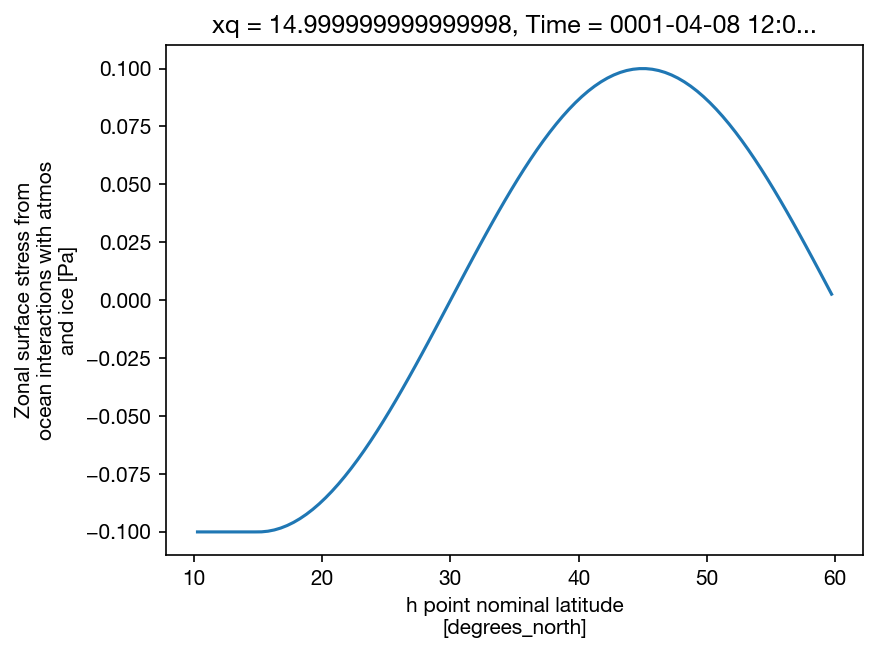

In [33]:
forcing_diag.taux.isel(time=-1,xq=30).plot()

In [40]:
365*2

730